In [1]:

from pathlib import Path
# 建议在包根目录 `counterfactual_spatial_cvae/` 下启动 Jupyter，使 `data/` 与 `counterfactual_spatial_cvae/` 包同级可 import
NOTEBOOK_CWD = Path.cwd()

# ---------- 按需修改 ----------
CONFIG = {
    "sample_id": "151509",
    # Visium：filtered_feature_bc_matrix 所在样本目录
    "visium_root": Path("/home_nfs/sifan.miao/STcode/data/DLPFC/DLPFC_raw"),
    # layer 注释：{sample}_truth.txt
    "truth_root": Path("/home_nfs/sifan.miao/STcode/data/DLPFC/DLPFC_raw"),
    # 模拟 h5ad 输出目录（相对于当前工作目录）
    "output_dir": NOTEBOOK_CWD / "data" / "MOSTA"
}

CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)
print("CWD:", NOTEBOOK_CWD)
print("Output:", CONFIG["output_dir"])

CWD: /home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae
Output: /home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/data/MOSTA


In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import gc# 若 Cell 5 跑完还留着
gc.collect()

0

In [4]:
 import scanpy as sc
 adata_A=sc.read_h5ad("/home_nfs/sifan.miao/1/data/MOSTA/original/E12.5_E1S1.MOSTA.h5ad")
 adata_B=sc.read_h5ad("/home_nfs/sifan.miao/1/data/MOSTA/original/E14.5_E1S1.MOSTA .h5ad")

In [5]:
import sys

PKG_ROOT = Path(".").resolve()
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from counterfactual_spatial_cvae import (
    CounterfactualSpatialCVAE,
    prepare_paired_anndata_with_slat,
    preset_fig3_recommended,
    recommend_batch_size,
)

ad_ref, ad_qry, ad0_raw, ad1_raw = prepare_paired_anndata_with_slat(
    adata_A,
    adata_B,
    subsample_n_obs=10000,
    copy=True,
)

# # STEP + recon-first + spatial=0 (see config.preset_fig3_recommended)
preset = preset_fig3_recommended()
device = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
model = CounterfactualSpatialCVAE.from_adata(
    ad0_raw, ad1_raw, model_config=preset.model, device=device
)
train_cfg = preset.training
train_cfg.n_per_batch = recommend_batch_size(ad0_raw.n_obs, ad1_raw.n_obs, cap=1024)
train_cfg.verbose = True
history = model.fit(train_cfg)

# import matplotlib.pyplot as plt

# epochs = range(1, len(history["epoch_total"]) + 1)
# fig, axes = plt.subplots(2, 2, figsize=(10, 7))
# axes[0, 0].plot(epochs, history["epoch_total"], label="total")
# axes[0, 0].set_title("total loss")
# axes[0, 1].plot(epochs, history["epoch_recon_A"], label="recon_A")
# axes[0, 1].plot(epochs, history["epoch_recon_B"], label="recon_B")
# axes[0, 1].legend(); axes[0, 1].set_title("reconstruction")
# axes[1, 0].plot(epochs, history["epoch_kld"], label="kld")
# axes[1, 0].plot(epochs, history["epoch_counterfactual"], label="cf")
# axes[1, 0].legend(); axes[1, 0].set_title("kld / counterfactual (unweighted)")
# axes[1, 1].plot(epochs, history["epoch_spatial"], label="spatial")
# axes[1, 1].set_title("spatial (unweighted)")
# for ax in axes.flat:
#     ax.set_xlabel("epoch")
# plt.tight_layout()
# plt.show()

# print("final total:", history["epoch_total"][-1])
# print("epochs:", len(history["epoch_total"]))

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/libpyg.so: undefined symbol: _ZN3c109TupleTypeC1ESt6vectorINS_4Type24SingletonOrSharedTypePtrIS2_EESaIS4_EESt8optionalINS_13QualifiedNameEESt10shared_ptrINS_14FunctionSchemaEE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/libpyg.so: undefined symbol: _ZN3c109TupleTypeC1ESt6vectorINS_4Type24SingletonOrSharedTypePtrIS2_EESaIS4_EESt8optionalINS_13QualifiedNameEESt10shared_ptrINS_14FunctionSchemaEE
  warnings.warn(f"An issue occurred while importing

Calculating spatial neighbor graph ...
The graph contains 218760 edges, 10000 cells.
21.876 neighbors per cell on average.
Calculating spatial neighbor graph ...
The graph contains 219642 edges, 10000 cells.
21.9642 neighbors per cell on average.
Use pca feature to format graph


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/merge.py:1033: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/merge.py:1033: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

Choose GPU:0 as device
Running
---------- epochs: 1 ----------
---------- epochs: 2 ----------
---------- epochs: 3 ----------
---------- epochs: 4 ----------
---------- epochs: 5 ----------
---------- epochs: 6 ----------
Training model time: 0.80
common genes: 27436


/home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/counterfactual_spatial_cvae/preprocess_slat.py:187: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata2.obs['batch'] = '1'
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

Epoch 196/200:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 197/200:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 198/200:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 199/200:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 200/200:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
result = model.compute_drift_score(
    ad0_raw, ad1_raw,
    min_expr_logcpm=0.0,
    top_n_perturb=3000,
    n_grid=1000,
    alpha=0,
    blacklist=True,
    batch_size=1024,
)

In [7]:
import pandas as pd

result = pd.read_csv("/home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/RECAST_0603.csv")

## Notes

See `README.md` for preset descriptions.


In [8]:
import numpy as np
def _to_numpy(x) -> np.ndarray:
        """将张量转换为 numpy 数组"""
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)
model.eval()
device = next(model.parameters()).device

# A→A (自编码), A→B (跨域预测)
XAA, XAB = model.get_all_predictions(ad0_raw, which_enc="A", batch_size=1024)
# B→B (自编码), B→A (跨域预测)
XBA, XBB = model.get_all_predictions(ad1_raw, which_enc="B", batch_size=1024)

In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

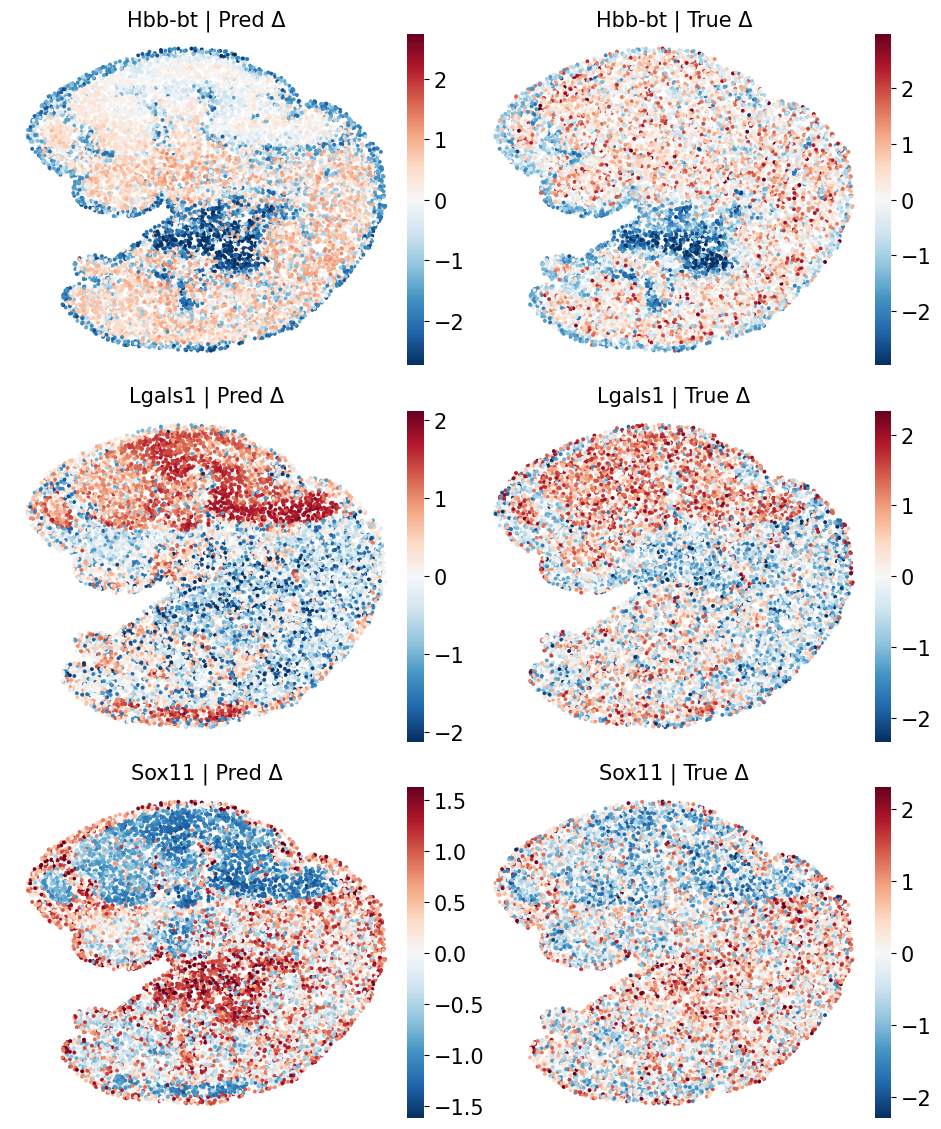

['Hbb-bt', 'Lgals1', 'Sox11']

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_reconstruction_vs_true_diff(
    adata_ref,
    adata_cf,
    X_ref_model,
    X_cf_model,
    gene_list,
    *,
    # coords
    coords_key="spatial",
    invert_y=True,
    # true layer
    layer_true="log_norm",
    # model -> log_norm (如果模型输出不是log_norm，这步很重要)
    use_library_size=True,
    target_sum=1e4,
    # diff + scaling
    diff_mode="delta_log",      # 推荐：delta_log
    robust="none",              # none / mad / zscore（推荐 none 或 mad）
    clip_percentile=99.0,
    # color scaling mode
    cbar_mode="true_led",       # 推荐：true_led；independent/union 也可
    cmap="RdBu_r",
    spot_size=8,
    figsize_per_gene=(9.5, 3.8),
    # optional denoise
    use_region_avg=False,
    region_key="cell_name",
    min_region_cells=5,
    # layout
    wspace=0.02,
    cbar_pad=0.01,
    cbar_fraction=0.04,
    cbar_outline=False,
    show_spot_r=False,
):
    def _to_dense(x):
        return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

    if coords_key not in adata_ref.obsm:
        raise KeyError(f"adata_ref.obsm['{coords_key}'] missing")
    coords = np.asarray(adata_ref.obsm[coords_key], dtype=float)

    X_ref_true = _to_dense(adata_ref.layers[layer_true])
    X_cf_true  = _to_dense(adata_cf.layers[layer_true])
    # X_ref_true = _to_dense(adata_ref.X)
    # X_cf_true  = _to_dense(adata_cf.X)

    X_ref_model = np.asarray(X_ref_model)
    X_cf_model  = np.asarray(X_cf_model)

    if use_library_size:
        lib = np.asarray(adata_ref.obs["library_size"]).reshape(-1, 1)
        X_ref_model = np.log1p((X_ref_model / (lib + 1e-8)) * target_sum)
        X_cf_model  = np.log1p((X_cf_model  / (lib + 1e-8)) * target_sum)

    def _standardize(v):
        v = np.asarray(v, dtype=float)
        m = np.isfinite(v)
        if robust == "none" or m.sum() < 3:
            return v
        if robust == "zscore":
            mu = v[m].mean()
            sd = v[m].std()
            out = v.copy()
            out[m] = 0.0 if sd < 1e-8 else (v[m] - mu) / (sd + 1e-9)
            return out
        if robust == "mad":
            med = np.median(v[m])
            mad = np.median(np.abs(v[m] - med))
            out = v.copy()
            out[m] = (v[m] - med) / (1.4826 * (mad + 1e-9))
            return out
        raise ValueError("robust must be none/zscore/mad")

    if use_region_avg:
        labels_ref = np.asarray(adata_ref.obs[region_key].astype(str))
        labels_cf  = np.asarray(adata_cf.obs[region_key].astype(str))
        v1, c1 = np.unique(labels_ref, return_counts=True)
        v2, c2 = np.unique(labels_cf,  return_counts=True)
        valid = sorted(set(v1[c1 >= min_region_cells]) & set(v2[c2 >= min_region_cells]))
        if len(valid) == 0:
            raise ValueError("No overlapping regions for region_avg. Set use_region_avg=False or change region_key.")

    var_names = list(adata_ref.var_names)
    gene_to_idx = {g: i for i, g in enumerate(var_names)}

    kept = [g for g in gene_list if g in gene_to_idx]
    n = len(kept)
    fig, axes = plt.subplots(n, 2, figsize=(figsize_per_gene[0], figsize_per_gene[1] * max(n, 1)))
    fig.subplots_adjust(wspace=wspace)
    if n == 1:
        axes = np.expand_dims(axes, 0)

    for i, g in enumerate(kept):
        gi = gene_to_idx[g]

        if diff_mode != "delta_log":
            raise ValueError("diff_mode only supports 'delta_log' here")

        diff_model_spot = X_cf_model[:, gi] - X_ref_model[:, gi]
        diff_true_spot  = X_cf_true[:, gi]  - X_ref_true[:, gi]

        if use_region_avg:
            dm = np.full(len(labels_ref), np.nan)
            dt = np.full(len(labels_ref), np.nan)
            for reg in valid:
                mr = labels_ref == reg
                mc = labels_cf == reg
                dm[mr] = np.nanmean(diff_model_spot[mr])
                dt[mr] = np.nanmean(X_cf_true[mc, gi]) - np.nanmean(X_ref_true[mr, gi])
            diff_model = dm
            diff_true  = dt
        else:
            diff_model = diff_model_spot.astype(float)
            diff_true  = diff_true_spot.astype(float)

        diff_model = _standardize(diff_model)
        diff_true  = _standardize(diff_true)

        fm = np.isfinite(diff_model)
        ft = np.isfinite(diff_true)

        # color scaling
        if cbar_mode == "independent":
            vmax0 = np.percentile(np.abs(diff_model[fm]), clip_percentile) if fm.any() else 1.0
            vmax1 = np.percentile(np.abs(diff_true[ft]),  clip_percentile) if ft.any() else 1.0
            vmin0, vmax0 = -max(vmax0, 1e-12), max(vmax0, 1e-12)
            vmin1, vmax1 = -max(vmax1, 1e-12), max(vmax1, 1e-12)
        elif cbar_mode == "true_led":
            vmax = np.percentile(np.abs(diff_true[ft]), clip_percentile) if ft.any() else 1.0
            vmax = max(vmax, 1e-12)
            vmin0 = vmin1 = -vmax
            vmax0 = vmax1 =  vmax
        elif cbar_mode == "union":
            both = np.concatenate([np.abs(diff_model[fm]), np.abs(diff_true[ft])]) if (fm.any() or ft.any()) else np.array([1.0])
            vmax = max(float(np.percentile(both, clip_percentile)), 1e-12)
            vmin0 = vmin1 = -vmax
            vmax0 = vmax1 =  vmax
        else:
            raise ValueError("cbar_mode must be independent/true_led/union")

        # correlation (spot)
        m = fm & ft
        spot_r = pearsonr(diff_model[m], diff_true[m])[0] if m.sum() >= 3 else np.nan

        ax0, ax1 = axes[i, 0], axes[i, 1]
        im0 = ax0.scatter(coords[:, 0], coords[:, 1], c=diff_model, cmap=cmap, s=spot_size, vmin=vmin0, vmax=vmax0, linewidths=0)
        im1 = ax1.scatter(coords[:, 0], coords[:, 1], c=diff_true,  cmap=cmap, s=spot_size, vmin=vmin1, vmax=vmax1, linewidths=0)

        t0 = f"{g} | Pred Δ"
        t1 = f"{g} | True Δ"
        if show_spot_r and np.isfinite(spot_r):
            t1 += f"  (spot r={spot_r:.3f})"
        ax0.set_title(t0, fontsize=15)
        ax1.set_title(t1, fontsize=15)

        for ax in (ax0, ax1):
            if invert_y:
                ax.invert_yaxis()
            ax.axis("off")
        # one shared colorbar per row unless independent
        if cbar_mode == "independent":
            cb0 = fig.colorbar(im0, ax=ax0, fraction=cbar_fraction, pad=cbar_pad)
            cb1 = fig.colorbar(im1, ax=ax1, fraction=cbar_fraction, pad=cbar_pad)
            if not cbar_outline:
                cb0.outline.set_visible(False)
                cb1.outline.set_visible(False)
            cb0.ax.tick_params(labelsize=15)
            cb1.ax.tick_params(labelsize=15)
        else:
            cb = fig.colorbar(im1, ax=[ax0, ax1], fraction=cbar_fraction, pad=cbar_pad)
            if not cbar_outline:
                cb.outline.set_visible(False)

    plt.savefig("dela_gene.pdf", bbox_inches="tight")
    plt.savefig("dela_gene.svg", bbox_inches="tight")
    plt.tight_layout()
    plt.show()
    return kept
# gene_list = result_old["gene"][:10].tolist()
gene_list=["Hbb-bt","Lgals1","Sox11"]
# gene_list = result["gene"][10:20].tolist()
plot_reconstruction_vs_true_diff(
    ad0_raw, ad1_raw,
    XAA, XAB,
    gene_list,
    cbar_mode="independent",  # Pred/True 各自标尺
    robust="mad",          # 可选：让图更稳、更少被离群点影响；不想标准化就改 "none"
    clip_percentile=99,       # 可选：压掉极端值
    cmap="RdBu_r",
    spot_size=8,
    cbar_outline=False,       # 去掉色条黑框（可选）
)

In [5]:
import anndata as ad
def compute_deg_genes(ad0_raw, ad1_raw, top_n=2000):
    print("[DEG] Concatenating adata...")
    adata_combined = ad.concat(
        [adata_A, adata_B], 
        label="condition",
        keys=["E15.5", "E16.5"]
    )
    adata_combined.obs["condition"] = adata_combined.obs["condition"].astype(str)

    # ---------- 检查并准备用于 DEG 的表达矩阵 ----------
    # 假设原始计数存在 layers['count'] 中
    if "log_norm" not in adata_combined.layers:
        print("[DEG] Creating log_norm layer from counts...")
        # 备份原始 .X（如果 .X 不是 counts，可根据实际情况调整）
        # 这里假定 .X 可能已经被修改过，所以我们直接使用 layers['count']
        if "count" not in adata_combined.layers:
            raise KeyError("Neither 'log_norm' nor 'count' layer found. Please provide raw counts.")
        
        # 从 layers['count'] 复制一份做归一化
        adata_combined.layers["log_norm"] = adata_combined.layers["count"].copy()
        # 临时将 .X 指向该层，以便使用 sc.pp 函数
        original_X = adata_combined.X
        adata_combined.X = adata_combined.layers["log_norm"]
        # 执行文库大小归一化（target_sum=1e4 是典型值）
        sc.pp.normalize_total(adata_combined, target_sum=1e4, inplace=True)
        sc.pp.log1p(adata_combined)
        # 将结果存回 layers["log_norm"]，并恢复 .X
        adata_combined.layers["log_norm"] = adata_combined.X
        adata_combined.X = original_X   # 恢复原有 .X（如果有重要内容）
    else:
        # 已有 log_norm 层，直接使用
        adata_combined.X = adata_combined.layers["log_norm"]

    # 或者更简洁的方式：直接使用 layer 参数（scanpy >=1.9）
    # sc.tl.rank_genes_groups(..., layer='log_norm') 这样无需改动 .X

    print("[DEG] Running rank_genes_groups...")
    sc.tl.rank_genes_groups(
        adata_combined,
        groupby="condition",
        method="wilcoxon",
        n_genes=top_n,
        key_added="deg",
        layer='log_norm'   # 推荐：直接指定层，避免修改 .X
    )

    deg_df = sc.get.rank_genes_groups_df(
        adata_combined, 
        group="E16.5",
        key="deg"
    ).head(top_n)

    deg_genes = set(deg_df["names"].tolist())
    print(f"[DEG] Found {len(deg_genes)} genes")
    return deg_genes, deg_df
deg_genes, deg_df=compute_deg_genes(ad0_raw,ad1_raw)

[DEG] Concatenating adata...


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/merge.py:1033: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[DEG] Creating log_norm layer from counts...
[DEG] Running rank_genes_groups...
[DEG] Found 2000 genes


[Heatmap] Genes: 50
[Heatmap] Computing CF predictions (for heatmap)...
[Heatmap] Regions: 17
[Heatmap] Using provided XAA/XAB/XBB/XBA for R calculation (bidirectional)

Per-region Pearson r (computed with bidirectional delta):
  Brain                           r = 0.965
  Muscle                          r = 0.965
  Cavity                          r = 0.965
  Epidermis                       r = 0.954
  Cartilage primordium            r = 0.953
  Meninges                        r = 0.949
  Connective tissue               r = 0.944
  Kidney                          r = 0.927
  Mucosal epithelium              r = 0.923
  Heart                           r = 0.916
  Jaw and tooth                   r = 0.911
  Pancreas                        r = 0.893
  GI tract                        r = 0.885
  Dorsal root ganglion            r = 0.880
  Mesothelium                     r = 0.789
  Liver                           r = 0.785
  Choroid plexus                  r = 0.710


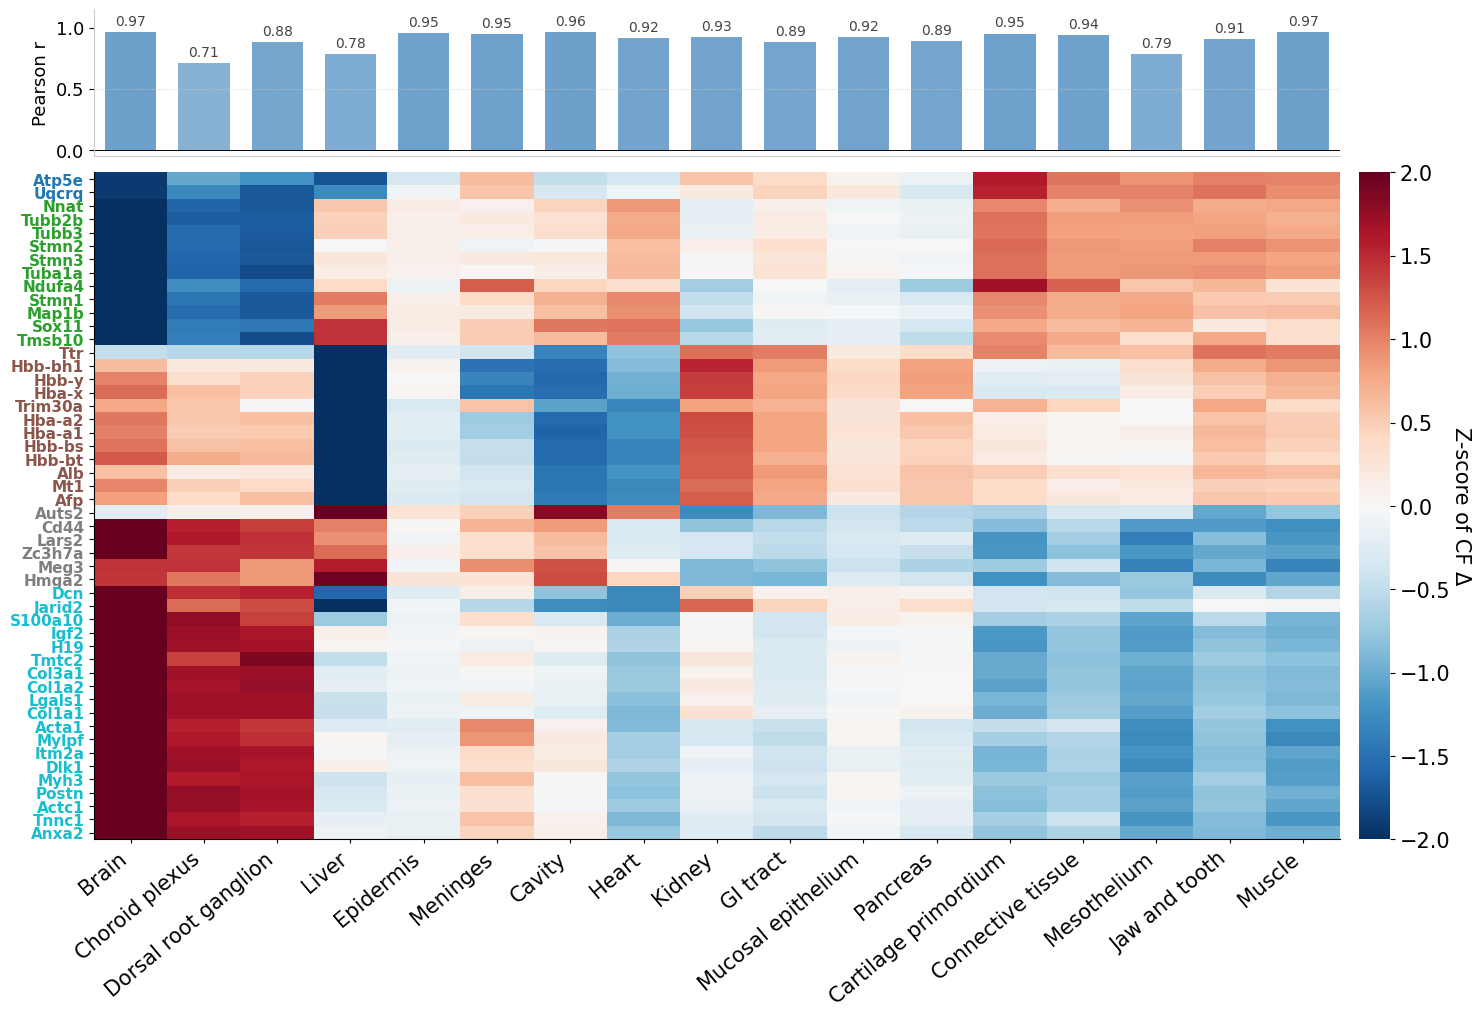

[Saved] heatmap_figure5B.svg


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mc
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings("ignore")
 
# ── gene group config ──────────────────────────────────────────────────────
GENE_GROUP_RULES = {
    "mt-":   "Mitochondria",
    "Uqcr":  "Mitochondria", "Cox":   "Mitochondria",
    "Atp5":  "Mitochondria", "Nduf":  "Mitochondria",
    "Hba":   "Haemoglobin",  "Hbb":   "Haemoglobin",
    "Rps":   "Ribosome",     "Rpl":   "Ribosome",
    "Col":   "ECM",          "Fn1":   "ECM",
    "Postn": "ECM",          "Dcn":   "ECM",
    "Acta":  "Cytoskeleton", "Actc":  "Cytoskeleton",
    "Tmsb":  "Cytoskeleton", "Vim":   "Cytoskeleton",
    "Tubb":  "Cytoskeleton", "Tuba":  "Cytoskeleton",
    "Stmn":  "Cytoskeleton", "Crmp":  "Cytoskeleton",
    "Map":   "Cytoskeleton",
    "Myl":   "Muscle",       "Mylp":  "Muscle",
    "Tnni":  "Muscle",       "Tnnc":  "Muscle",
    "Myh":   "Muscle",       "Myh":   "Muscle",
    "Afp":   "Liver",        "Alb":   "Liver",
    "Apoa":  "Liver",        "Apoe":  "Liver",
    "Lgals": "Cell Adhesion","Cd44":  "Cell Adhesion",
    "Itm":   "Cell Adhesion","Anxa":  "Cell Adhesion",
    "Igf":   "Imprinting",   "Dlk":   "Imprinting",
    "H19":   "Imprinting",   "Nnat":  "Imprinting",
    "Mt1":   "Stress",       "Mt2":   "Stress",
    "Trim":  "Immune",       "Cd24":  "Immune",
    "Cdk":   "Cell Cycle",
}
 
GROUP_PALETTE = {
    "Haemoglobin":   "#B22222",
    "Muscle":        "#E64B35",
    "ECM":           "#00A087",
    "Cytoskeleton":  "#3CB371",
    "Liver":         "#F4A460",
    "Cell Adhesion": "#DDA0DD",
    "Imprinting":    "#DC143C",
    "Stress":        "#8B6914",
    "Mitochondria":  "#FF6347",
    "Ribosome":      "#4DBBD5",
    "Immune":        "#9370DB",
    "Cell Cycle":    "#8491B4",
    "Other":         "#888888",
}
 
GROUP_ORDER = [
    "Haemoglobin", "Muscle", "ECM", "Cytoskeleton",
    "Liver", "Cell Adhesion", "Imprinting",
    "Mitochondria", "Stress", "Ribosome",
    "Immune", "Cell Cycle", "Other",
]
 
 
def _assign_gene_group(gene: str) -> str:
    for prefix, group in GENE_GROUP_RULES.items():
        if gene.startswith(prefix) or gene == prefix:
            return group
    return "Other"
 
 
def _get_counterfactual_delta(
    model, adata, which_enc: str, top_genes: list,
    batch_size: int = 1024, signed: bool = True,
) -> pd.DataFrame:
    """
    Returns DataFrame (n_cells × n_genes).
    signed=True  → XAB - XAA  (directed, red=up in B, blue=up in A)
    signed=False → |XAB - XAA| (magnitude only)
    """
    XAA_np, XAB_np = model.get_all_predictions(
        adata, which_enc=which_enc, batch_size=batch_size)
 
    # log1p CPM scale for comparability
    import scipy.sparse as sp
    lib = np.array(adata.obs["library_size"]).reshape(-1, 1)
    XAA_log = np.log1p(XAA_np / lib * 1e4)
    XAB_log = np.log1p(XAB_np / lib * 1e4)
 
    delta = XAB_log - XAA_log if signed else np.abs(XAB_log - XAA_log)
 
    gene_names = np.array(adata.var_names)
    gene_idx   = [np.where(gene_names == g)[0][0]
                  for g in top_genes if g in gene_names]
    genes_used = [g for g in top_genes if g in gene_names]
 
    return pd.DataFrame(delta[:, gene_idx], columns=genes_used,
                        index=adata.obs_names)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.sparse as sp
 
# ── palette ──────────────────────────────────────────────────────────────────
BLUE    = "#699ECA"
ORANGE  = "#FF8C00"
PINK    = "#F898CB"
GREEN   = "#4DAF4A"
BLUE_D  = "#3A6A9A"
ORG_D   = "#C46800"
 
PAL = {"AA": BLUE, "AB": ORANGE, "BB": PINK, "BA": GREEN}
 
# ── shared helpers ────────────────────────────────────────────────────────────
def _to_np(x):
    return x.numpy() if hasattr(x, "numpy") else np.array(x)
 
def _lognorm(adata):
    x = adata.layers["log_norm"]
    return x.toarray() if sp.issparse(x) else np.array(x)
 
def _cpm_scale(X, lib):
    median_lib = np.median(lib)
    return np.log1p(X / (lib + 1e-9) * median_lib)
 
def _norm_log1p(X, target=1e4):
    row_sums = X.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return np.log1p(X / row_sums * target)
def _cpm(X_count, lib_size, target=1e4):
    lib = lib_size.reshape(-1, 1) if lib_size.ndim == 1 else lib_size
    return np.log1p(X_count / lib * target)
def _clean_ax(ax):
    """Only bottom + left spines, black, no top/right."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(colors="black", labelsize=9, width=0.8)
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
def plot_spatial_region_heatmap(
    model,
    adata_A,
    adata_B,
    dsep_df: pd.DataFrame,
    region_metrics_dff: pd.DataFrame = None,
    top_n: int = 35,
    annotation_key: str = "cell_name",
    batch_size: int = 1024,
    min_region_cells: int = 10,
    signed: bool = True,
    figsize: tuple = (16, 10),
    save_path: str = "spatial_region_heatmap.png",
    dpi: int = 1200,
    condition_names=("E15.5", "E16.5"),
    n_gene_clusters: int = 5,
    XAA=None, XAB=None, XBB=None, XBA=None,  # 新增：用于R计算的双向数据
):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
    from scipy.spatial.distance import pdist
    from scipy.stats import zscore, pearsonr
    import matplotlib.cm as cm
    import scipy.sparse as sp
    FS_BAR_YLABEL = 11      # 柱状图 Y 轴标题
    FS_BAR_YTICK  = 10      # 柱状图 Y 轴数字 + 柱顶 r 值
    FS_HM_X       = 11      # 热图横坐标
    FS_HM_Y       = 6       # 热图纵坐标
    FS_CB         = 10      # colorbar 数字
    
    condA, condB = condition_names

    # ── 1. top genes ──────────────────────────────────────────
    top_genes = [
        g for g in dsep_df["gene"].values[:top_n]
        if not g.startswith("Gm") and not g.startswith("D13")
        and g in adata_A.var_names and g in adata_B.var_names
    ]
    print(f"[Heatmap] Genes: {len(top_genes)}")
    gene_idx = np.array([list(adata_A.var_names).index(g) for g in top_genes])

    # ── 2. 热图：用原始model预测方式计算 ───────────────────────
    print(f"[Heatmap] Computing CF predictions (for heatmap)...")
    delta_A = _get_counterfactual_delta(
        model, adata_A, "A", top_genes, batch_size, signed=signed)
    delta_B = -_get_counterfactual_delta(
        model, adata_B, "B", top_genes, batch_size, signed=signed)

    # 热图用的real data（原始预处理方式）
    def _prep(adata, gene_idx):
        x = adata.layers["log_norm"]
        if sp.issparse(x): x = x.toarray()
        x = np.array(x, dtype=np.float32)[:, gene_idx]
        lib = np.array(adata.obs["library_size"]).reshape(-1, 1)
        return _cpm_scale(x, lib)

    real_A_prep = _prep(adata_A, gene_idx)
    real_B_prep = _prep(adata_B, gene_idx)

    # ── 3. region labels ──────────────────────────────────────
    labels_A = np.array(adata_A.obs[annotation_key].astype(str).values)
    labels_B = np.array(adata_B.obs[annotation_key].astype(str).values)

    def _valid(labels, n): 
        v, c = np.unique(labels, return_counts=True)
        return set(v[c >= n])

    keep = sorted(_valid(labels_A, min_region_cells) & _valid(labels_B, min_region_cells))
    print(f"[Heatmap] Regions: {len(keep)}")

    # ── 4. 热图数据：原始双向平均方式 ─────────────────────────
    rA_pred = np.array([delta_A[labels_A == r].mean(0) for r in keep])
    rB_pred = np.array([delta_B[labels_B == r].mean(0) for r in keep])
    hm_pred = (rA_pred + rB_pred) / 2.0  # 热图用这个

    rA_real = np.array([real_A_prep[labels_A == r].mean(0) for r in keep])
    rB_real = np.array([real_B_prep[labels_B == r].mean(0) for r in keep])
    delta_real_heatmap = rB_real - rA_real

    # ── 5. R计算：用传入的双向数据（如果提供）───────────────
    if XAA is not None and XAB is not None and XBB is not None and XBA is not None:
        print("[Heatmap] Using provided XAA/XAB/XBB/XBA for R calculation (bidirectional)")
        # 用传入的数据重新计算region means
        lib_A = np.array(adata_A.obs["library_size"]).reshape(-1, 1)
        lib_B = np.array(adata_B.obs["library_size"]).reshape(-1, 1)
        
        XAA_log = _cpm(_to_np(XAA), lib_A)
        XAB_log = _cpm(_to_np(XAB), lib_A)
        XBB_log = _cpm(_to_np(XBB), lib_B)
        XBA_log = _cpm(_to_np(XBA), lib_B)
        real_A_simple = _lognorm(adata_A)
        real_B_simple = _lognorm(adata_B)

        def _region_means(mat, labels, regions):
            return np.array([mat[labels == r].mean(axis=0) for r in regions])

        # 用简单预处理的real data
        rA_shared_r = _region_means(real_A_simple[:, gene_idx], labels_A, keep)
        rB_shared_r = _region_means(real_B_simple[:, gene_idx], labels_B, keep)
        
        # 双向平均的pred delta
        AA_r = _region_means(XAA_log[:, gene_idx], labels_A, keep)
        AB_r = _region_means(XAB_log[:, gene_idx], labels_A, keep)
        BB_r = _region_means(XBB_log[:, gene_idx], labels_B, keep)
        BA_r = _region_means(XBA_log[:, gene_idx], labels_B, keep)
        
        delta_pred_AB_r = AB_r - AA_r
        delta_pred_BA_r = BB_r - BA_r
        hm_pred_r = (delta_pred_AB_r + delta_pred_BA_r) / 2.0
        
        delta_real_r = rB_shared_r - rA_shared_r
    else:
        print("[Heatmap] Using model predictions for R calculation")
        hm_pred_r = hm_pred
        delta_real_r = delta_real_heatmap

    # ── 6. 计算R ─────────────────────────────────────────────
    if region_metrics_dff is not None:
        region_metrics_dict = region_metrics_dff.set_index("region")[["pearson"]].to_dict()["pearson"]
        region_r = np.array([region_metrics_dict.get(r, np.nan) for r in keep])
        print("\nPer-region Pearson r (from region_metrics_dff):")
    else:
        region_r = []
        for i in range(len(keep)):
            dp, dr = hm_pred_r[i], delta_real_r[i]
            mask = np.isfinite(dp) & np.isfinite(dr)
            r = pearsonr(dp[mask], dr[mask])[0] if mask.sum() >= 3 else np.nan
            region_r.append(r)
        region_r = np.array(region_r)
        print("\nPer-region Pearson r (computed with bidirectional delta):")
    
    for reg, r in sorted(zip(keep, region_r), key=lambda x: -x[1] if not np.isnan(x[1]) else float('-inf')):
        print(f"  {reg:<30s}  r = {r:.3f}")

    # ── 7. Z-score + 双向聚类（基于热图数据hm_pred）──────────
    hm_df = pd.DataFrame(hm_pred.T, index=top_genes, columns=keep)
    hm_z = hm_df.apply(zscore, axis=1, result_type="expand")
    hm_z.columns = keep
    hm_z = hm_z.fillna(0)

    gene_link = linkage(pdist(hm_z.values, "euclidean"), method="ward")
    gene_cls = fcluster(gene_link, t=n_gene_clusters, criterion="maxclust")
    gene_order = leaves_list(gene_link)
    hm_z = hm_z.iloc[gene_order]
    ordered_genes = hm_z.index.tolist()
    cls_map = dict(zip(hm_z.index, gene_cls[gene_order]))

    cls_colors = cm.tab10(np.linspace(0, 1, n_gene_clusters))
    gene_color_map = {g: cls_colors[cls_map[g]-1] for g in ordered_genes}

    col_link = linkage(pdist(hm_z.T.values, "euclidean"), method="ward")
    col_order = leaves_list(col_link)
    hm_z = hm_z.iloc[:, col_order]
    region_order = list(hm_z.columns)

    r_lookup = dict(zip(keep, region_r))
    r_vals = np.array([r_lookup.get(r, np.nan) for r in region_order])

    # ── 8. 创建图形布局 ──────────────────────────────────────
    fig = plt.figure(figsize=figsize, facecolor="white")
    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        height_ratios=[0.22, 1],
        width_ratios=[1, 0.025],
        hspace=0.04, wspace=0.03,
        left=0.12, right=0.93,
        top=0.93, bottom=0.10,
    )
    ax_bar = fig.add_subplot(gs[0, 0])
    ax_hm = fig.add_subplot(gs[1, 0])
    ax_cb = fig.add_subplot(gs[1, 1])

    # ── 9. Pearson r 柱状图 ───────────────────────────────────
    BLUE = "#699ECA"
    ORANGE = "#FF8C00"

    for j, r in enumerate(r_vals):
        if np.isnan(r):
            continue
        color = BLUE if r >= 0 else ORANGE
        alpha = 0.3 + 0.7 * min(abs(r), 1.0)
        ax_bar.bar(j, r, color=color, alpha=alpha, width=0.7, linewidth=0)

    ax_bar.axhline(0, color="black", lw=0.7)
    ax_bar.axhline(0.5, color="#CCCCCC", lw=0.6, ls=":")

    for j, r in enumerate(r_vals):
        if not np.isnan(r) and abs(r) >= 0.5:
            va = "bottom" if r >= 0 else "top"
            off = 0.03 if r >= 0 else -0.03
            ax_bar.text(j, r + off, f"{r:.2f}",
                        ha="center", va=va,
                        fontsize=10, color="#444444", rotation=0)

    r_min = min(np.nanmin(r_vals) - 0.1, -0.05)
    ax_bar.set_xlim(-0.5, len(r_vals) - 0.5)
    ax_bar.set_ylim(r_min, 1.15)
    ax_bar.set_xticks([])
    ax_bar.set_ylabel("Pearson r", fontsize=13)
    ax_bar.set_yticks([0, 0.5, 1.0])
    ax_bar.tick_params(axis="y", labelsize=13)
    for sp in ("top", "right"):
        ax_bar.spines[sp].set_visible(False)
    for sp in ax_bar.spines.values():
        sp.set_color("#CCCCCC")

    # ── 10. 热图（基于原始model预测数据）───────────────────────
    norm_hm = plt.Normalize(vmin=-2, vmax=2)
    im = ax_hm.imshow(
        hm_z.values, aspect="auto",
        cmap=plt.cm.RdBu_r, norm=norm_hm,
        interpolation="nearest",
    )

    ax_hm.set_xticks(np.arange(len(hm_z.columns)))
    ax_hm.set_xticklabels(hm_z.columns, rotation=40, ha="right", fontsize=15)
    ax_hm.tick_params(axis="x", length=3)

    ax_hm.set_yticks(np.arange(len(hm_z.index)))
    ax_hm.set_yticklabels(hm_z.index, fontsize=11)
    for tick, gene in zip(ax_hm.get_yticklabels(), hm_z.index):
        tick.set_color(gene_color_map[gene])
        tick.set_fontweight("bold")

    ax_hm.set_xticks(np.arange(-0.5, len(hm_z.columns), 1), minor=True)
    ax_hm.set_yticks(np.arange(-0.5, len(hm_z.index), 1), minor=True)
    ax_hm.tick_params(which="minor", bottom=False, left=False)
    
    for sp in ("top", "right"):
        ax_hm.spines[sp].set_visible(False)

    # ── 11. 颜色条 ────────────────────────────────────────────
    cb = plt.colorbar(im, cax=ax_cb)
    cb.set_label(
        "Z-score of CF Δ" if signed else "Z-score of |CF Δ|",
        fontsize=15, rotation=270, labelpad=15,
    )
    cb.ax.tick_params(labelsize=15)

    # 去掉 colorbar 的黑色边框
    cb.outline.set_visible(False)

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {save_path}")

    return hm_z, dict(zip(region_order, r_vals))
hm_z,_=plot_spatial_region_heatmap(model, ad0_raw, ad1_raw,result_old,
    XAA=XAA, XAB=XAB, XBB=XBB, XBA=XBA,
    region_metrics_dff= None,
    top_n = 51,
    annotation_key="annotation",save_path="heatmap_figure5B.svg")

In [32]:
import os
print(os.path.abspath('.')) 

/home_nfs/sifan.miao


  [重构质量]
  Corr(XAA, real E12.5)          = 0.9821
  Corr(XBB, real E14.5)          = 0.9853
  [CF迁移准确性]
  Corr(XAB, real E14.5 target)   = 0.9858
  Corr(XBA, real E12.5 target)   = 0.9825
  [与源条件距离]
  Corr(XAB, real E12.5 source)   = 0.9218
  Corr(XBA, real E14.5 source)   = 0.8992
  [双向一致性]
  Pearson  r(ΔA, −ΔB)             = 0.9979
  Spearman ρ(ΔA, −ΔB)             = 0.9968


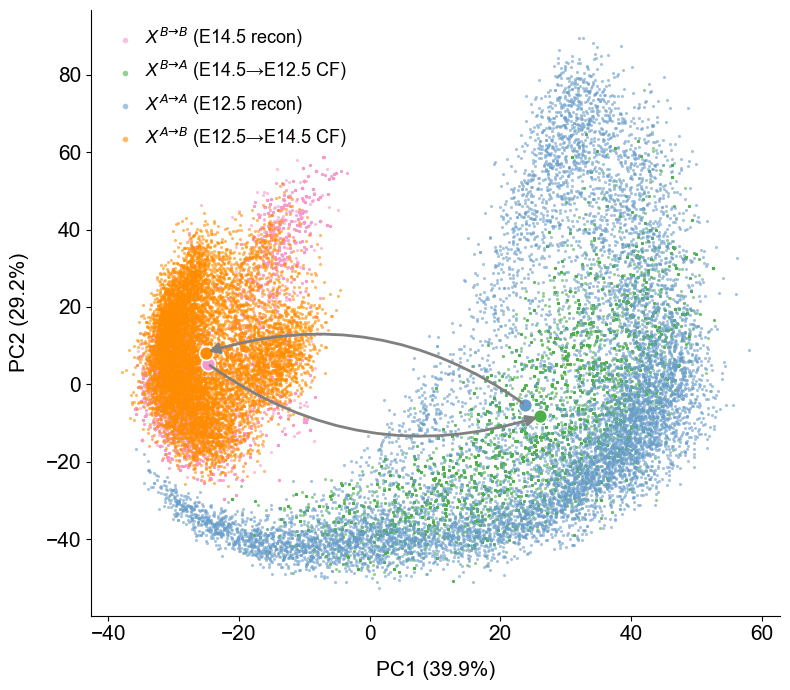

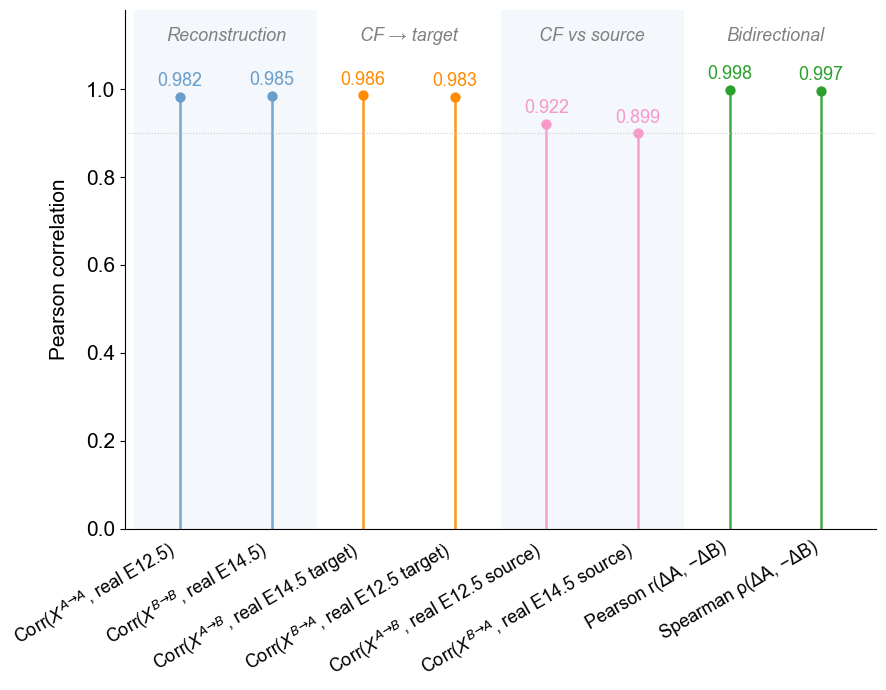

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.sparse as sp
 
# ── palette ──────────────────────────────────────────────────────────────────
BLUE    = "#699ECA"
ORANGE  = "#FF8C00"
PINK    = "#F898CB"
GREEN   = "#4DAF4A"
BLUE_D  = "#3A6A9A"
ORG_D   = "#C46800"
 
PAL = {"AA": BLUE, "AB": ORANGE, "BB": PINK, "BA": GREEN}
 
# ── shared helpers ────────────────────────────────────────────────────────────
def _to_np(x):
    return x.numpy() if hasattr(x, "numpy") else np.array(x)
 
def _lognorm(adata):
    x = adata.layers["log_norm"]
    return x.toarray() if sp.issparse(x) else np.array(x)
 
def _cpm_scale(X, lib):
    median_lib = np.mean(lib)
    return np.log1p(X / (lib + 1e-9) * median_lib)
 
def _norm_log1p(X, target=1e4):
    row_sums = X.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return np.log1p(X / row_sums * target)
def normalize_per_slice(X):
    X = X / (X.sum(axis=1, keepdims=True) + 1e-8) * 1e4
    X = np.log1p(X)
    return X


def _model_log_cpm(X, lib, target_sum=1e4):
    """Model counts -> log1p(CPM); matches training counterfactual_loss & plot_reconstruction."""
    X = _to_np(X)
    lib = np.asarray(lib, dtype=float).reshape(-1, 1)
    return np.log1p((X / (lib + 1e-8)) * target_sum)
def _clean_ax(ax):
    """Only bottom + left spines, black, no top/right."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(colors="black", labelsize=9, width=0.8)
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
 
 

# Re-run this entire cell after edits; then re-run plot_cf_combined(...) below.
gene_list = result["gene"][:1000].tolist()


def plot_cf_combined(
    XAA, XAB, XBB, XBA,
    adata_A, adata_B,
    df_score=None,
    top_n_genes: int = 2000,
    condition_names=("E12.5", "E14.5"),
    n_subsample: int = 10000,
    gene_list=None,
    highlight_genes=None,
    delta_s: int = 15,
    delta_alpha: float = 0.3,
):
    condA, condB = condition_names

    # ── 1. normalize ─────────────────────────────────────────
    # XAA_log = normalize_per_slice(_to_np(XAA))
    # XAB_log = normalize_per_slice(_to_np(XAB))
    # XBB_log = normalize_per_slice(_to_np(XBB))
    # XBA_log = normalize_per_slice(_to_np(XBA))
    # real_A  = _lognorm(adata_A)
    # real_B  = _lognorm(adata_B)
    lib_A = np.asarray(adata_A.obs["library_size"], dtype=float).reshape(-1, 1)
    lib_B = np.asarray(adata_B.obs["library_size"], dtype=float).reshape(-1, 1)

    XAA_log = _model_log_cpm(XAA, lib_A)
    XAB_log = _model_log_cpm(XAB, lib_A)
    XBB_log = _model_log_cpm(XBB, lib_B)
    XBA_log = _model_log_cpm(XBA, lib_B)
    real_A  = _lognorm(adata_A)
    real_B  = _lognorm(adata_B)
    gene_names = list(adata_A.var_names)

    # ── 2. top genes ──────────────────────────────────────────
    if df_score is not None and len(df_score) > 0:
        top_genes = [g for g in df_score["gene"].values
                     if g in gene_names][:top_n_genes]
    else:
        var = XAA_log.var(0) + XBB_log.var(0)
        top_genes = [gene_names[i]
                     for i in np.argsort(var)[::-1][:top_n_genes]]
    top_idx = np.array([gene_names.index(g) for g in top_genes])

    # ── 3. gene-level means ───────────────────────────────────
    mean_XAA = XAA_log[:, top_idx].mean(0)
    mean_XAB = XAB_log[:, top_idx].mean(0)
    mean_XBB = XBB_log[:, top_idx].mean(0)
    mean_XBA = XBA_log[:, top_idx].mean(0)
    mean_rA  = real_A[:,  top_idx].mean(0)
    mean_rB  = real_B[:,  top_idx].mean(0)

    # ── 4. 六个核心指标（全部和真实值比，基准统一）─────────
    # 重构质量
    r_recon_A, _ = pearsonr(mean_XAA, mean_rA)   # XAA vs real A
    r_recon_B, _ = pearsonr(mean_XBB, mean_rB)   # XBB vs real B

    # CF迁移准确性（预测值和目标条件真实值比）
    r_cf_AB_target, _ = pearsonr(mean_XAB, mean_rB)  # XAB vs real B (target)
    r_cf_BA_target, _ = pearsonr(mean_XBA, mean_rA)  # XBA vs real A (target)

    # 与源条件的距离（预测值和源条件真实值比，应低于target）
    r_cf_AB_source, _ = pearsonr(mean_XAB, mean_rA)  # XAB vs real A (source)
    r_cf_BA_source, _ = pearsonr(mean_XBA, mean_rB)  # XBA vs real B (source)

    # ── 5. 双向一致性 ─────────────────────────────────────────
    # XAA_n = _norm_log1p(_to_np(XAA))
    # XAB_n = _norm_log1p(_to_np(XAB))
    # XBB_n = _norm_log1p(_to_np(XBB))
    # XBA_n = _norm_log1p(_to_np(XBA))
    delta_A     = (XAB_log - XAA_log).mean(axis=0)
    neg_delta_B = -(XBA_log - XBB_log).mean(axis=0)
    # delta_A     = (XAB_n - XAA_n).mean(axis=0)
    # neg_delta_B = -(XBA_n - XBB_n).mean(axis=0)

    if gene_list is not None:
        mask        = np.isin(np.array(gene_names), gene_list)
        delta_A     = delta_A[mask]
        neg_delta_B = neg_delta_B[mask]

    r_delta,   _ = pearsonr(delta_A, neg_delta_B)
    rho_delta, _ = spearmanr(delta_A, neg_delta_B)

    # ── 6. 打印汇总 ───────────────────────────────────────────
    print("=" * 55)
    print(f"  [重构质量]")
    print(f"  Corr(XAA, real {condA})          = {r_recon_A:.4f}")
    print(f"  Corr(XBB, real {condB})          = {r_recon_B:.4f}")
    print(f"  [CF迁移准确性]")
    print(f"  Corr(XAB, real {condB} target)   = {r_cf_AB_target:.4f}")
    print(f"  Corr(XBA, real {condA} target)   = {r_cf_BA_target:.4f}")
    print(f"  [与源条件距离]")
    print(f"  Corr(XAB, real {condA} source)   = {r_cf_AB_source:.4f}")
    print(f"  Corr(XBA, real {condB} source)   = {r_cf_BA_source:.4f}")
    print(f"  [双向一致性]")
    print(f"  Pearson  r(ΔA, −ΔB)             = {r_delta:.4f}")
    print(f"  Spearman ρ(ΔA, −ΔB)             = {rho_delta:.4f}")
    print("=" * 55)

    # ══════════════════════════════════════════════════════════
    # Figure 1: PCA
    # ══════════════════════════════════════════════════════════
    np.random.seed(42)
    nA, nB = XAA_log.shape[0], XBB_log.shape[0]
    sA = np.random.choice(nA, min(n_subsample, nA), replace=False)
    sB = np.random.choice(nB, min(n_subsample, nB), replace=False)

    AA_sub = XAA_log[sA][:, top_idx]
    AB_sub = XAB_log[sA][:, top_idx]
    BB_sub = XBB_log[sB][:, top_idx]
    BA_sub = XBA_log[sB][:, top_idx]

    X_all  = np.vstack([AA_sub, AB_sub, BB_sub, BA_sub])
    labels = np.array(
        ["AA"] * len(AA_sub) + ["AB"] * len(AB_sub) +
        ["BB"] * len(BB_sub) + ["BA"] * len(BA_sub)
    )
    pca_obj = PCA(n_components=2, random_state=42)
    emb = pca_obj.fit_transform(StandardScaler().fit_transform(X_all))
    ev  = pca_obj.explained_variance_ratio_

    fig1, ax = plt.subplots(figsize=(8, 7), facecolor="white")
    # layer_order = [
    #     ("BB", PAL["BB"], f"XBB ({condB} recon)"),
    #     ("BA", PAL["BA"], f"XBA ({condB}→{condA} CF)"),
    #     ("AA", PAL["AA"], f"$X^{{A \\to A}}$ ({condA} recon)"),
    #     ("AB", PAL["AB"], f"XAB ({condA}→{condB} CF)"),
    # ]
    # layer_order = [
    #     ("BB", PAL["BB"], f"$X^{{B \\to B}}$"),
    #     ("BA", PAL["BA"], f"$X^{{B \\to A}}$"),
    #     ("AA", PAL["AA"], f"$X^{{A \\to A}}$"),
    #     ("AB", PAL["AB"], f"$X^{{A \\to B}}$"),
    # ]
    layer_order = [
    ("BB", PAL["BB"], f"$X^{{B \\to B}}$ ({condB} recon)"),
    ("BA", PAL["BA"], f"$X^{{B \\to A}}$ ({condB}→{condA} CF)"),
    ("AA", PAL["AA"], f"$X^{{A \\to A}}$ ({condA} recon)"),
    ("AB", PAL["AB"], f"$X^{{A \\to B}}$ ({condA}→{condB} CF)"),
]
    for lbl, col, name in layer_order:
        m = labels == lbl
        ax.scatter(emb[m, 0], emb[m, 1],
                   s=5, alpha=0.6, color=col, label=name,
                   rasterized=True, linewidths=0)

    cxd = {lbl: emb[labels == lbl, 0].mean() for lbl, _, _ in layer_order}
    cyd = {lbl: emb[labels == lbl, 1].mean() for lbl, _, _ in layer_order}
    for lbl, col, _ in layer_order:
        ax.scatter(cxd[lbl], cyd[lbl], s=100, color=col,
                   edgecolors="white", linewidths=1.2, zorder=10)

    for src, dst, acol in [("BB", "BA", "#808080"), ("AA", "AB", "#808080")]:
        ax.annotate("",
                    xy=(cxd[dst], cyd[dst]),
                    xytext=(cxd[src], cyd[src]),
                    arrowprops=dict(arrowstyle="-|>", color=acol,
                                   lw=2.0, mutation_scale=16,
                                   connectionstyle="arc3,rad=0.25"),
                    zorder=12)

    ax.set_xlabel(f"PC1 ({ev[0]:.1%})", fontsize=15,labelpad=12)
    ax.set_ylabel(f"PC2 ({ev[1]:.1%})", fontsize=15,labelpad=12)
    _clean_ax(ax)
    ax.tick_params(axis='both', labelsize=15)
    ax.legend(fontsize=13, frameon=False, markerscale=1.8,
              loc="best", labelcolor="black",handletextpad=0.1,)
    fig1.tight_layout()
    fig1.savefig("pca_figure5C.pdf", bbox_inches="tight")
    fig1.savefig("pca_figure5C.svg", bbox_inches="tight")
    plt.show()

    # ══════════════════════════════════════════════════════════
    # Figure 2: Lollipop（8个指标，基准统一）
    # ══════════════════════════════════════════════════════════
    GREEN = "#2CA02C"
    groups = [
        # (标签, 值, 颜色, 组号)
        (f"Corr($X^{{A \\to A}}$, real {condA})",         r_recon_A,      BLUE,   0),
        (f"Corr($X^{{B \\to B}}$, real {condB})",         r_recon_B,      BLUE,   0),
        (f"Corr($X^{{A \\to B}}$, real {condB} target)",  r_cf_AB_target, ORANGE, 1),
        (f"Corr($X^{{B \\to A}}$, real {condA} target)",  r_cf_BA_target, ORANGE, 1),
        (f"Corr($X^{{A \\to B}}$, real {condA} source)",  r_cf_AB_source, PINK,   2),
        (f"Corr($X^{{B \\to A}}$, real {condB} source)",  r_cf_BA_source, PINK,   2),
        (f"Pearson r(ΔA, −ΔB)",             r_delta,        GREEN,  3),
        (f"Spearman ρ(ΔA, −ΔB)",            rho_delta,      GREEN,  3),
    ]
    group_names = ["Reconstruction", "CF → target", "CF vs source", "Bidirectional"]

    labels_c = [g[0] for g in groups]
    values_c = [g[1] for g in groups]
    colors_c = [g[2] for g in groups]
    gids     = [g[3] for g in groups]

    fig2, ax = plt.subplots(figsize=(9, 7), facecolor="white")

    group_bounds = {}
    for i, gid in enumerate(gids):
        group_bounds.setdefault(gid, [i, i])[1] = i

    band_colors = ["#F4F7FB", "#FFFFFF"]
    for gid, (lo, hi) in group_bounds.items():
        ax.axvspan(lo - 0.5, hi + 0.5,
                   color=band_colors[gid % 2], zorder=0)

    for i, (val, col) in enumerate(zip(values_c, colors_c)):
        ax.plot([i, i], [0, val], color=col, lw=1.8, alpha=0.9, zorder=1)
        ax.scatter(i, val, color=col, s=55, zorder=2, linewidths=0)
        ax.text(i, val + 0.015, f"{val:.3f}",
                va="bottom", ha="center", fontsize=13, color=col)

    ax.axhline(0,   color="#CCCCCC", lw=0.8)
    ax.axhline(0.9, color="#CCCCCC", lw=0.8, ls=":")

    for gid, (lo, hi) in group_bounds.items():
        mid = (lo + hi) / 2
        ax.text(mid, 1.1, group_names[gid],
                va="bottom", ha="center", fontsize=13,
                color="#808080", style="italic")

    ax.set_xticks(np.arange(len(labels_c)))
    ax.set_xticklabels(labels_c, fontsize=13, rotation=30, ha="right")
    for lbl in ax.get_xticklabels():
        lbl.set_color("black")

    ax.set_xlim(-0.6, len(labels_c) - 0.4)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Pearson correlation", fontsize=15, labelpad=12)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis="x", bottom=False)
    fig2.subplots_adjust(bottom=0.28)
    fig2.tight_layout()
    fig2.savefig("lollipop_figure5D.pdf", bbox_inches="tight")
    fig2.savefig("lollipop_figure5D.svg", bbox_inches="tight")
    plt.show()

    return {
        "r_recon_A":      r_recon_A,
        "r_recon_B":      r_recon_B,
        "r_cf_AB_target": r_cf_AB_target,
        "r_cf_BA_target": r_cf_BA_target,
        "r_cf_AB_source": r_cf_AB_source,
        "r_cf_BA_source": r_cf_BA_source,
        "r_delta":        r_delta,
        "rho_delta":      rho_delta,
    }
results = plot_cf_combined(
    XAA, XAB, XBB, XBA,
    ad0_raw, ad1_raw,
    df_score=result,
    top_n_genes=2000,
    condition_names=("E12.5", "E14.5"),
    gene_list=gene_list,          # delta scatter 过滤
    highlight_genes=[ ],
)